In [1]:
#install exploratory modelling workbench https://github.com/quaquel/EMAworkbench

#!pip install -U ema_workbench[recommended]

In [2]:
#import packages and checking versions

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
from ema_workbench.analysis import cart
from ema_workbench.analysis import prim
from ema_workbench.util import ema_logging

print(np.__version__)
print(np.__file__)
print(hasattr(np, "bool"))



c:\Users\5982758\AppData\Local\anaconda3\envs\prisma-summer\Lib\site-packages\ema_workbench\__init__.py:42: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  from . import em_framework, util


2.4.6
c:\Users\5982758\AppData\Local\anaconda3\envs\prisma-summer\Lib\site-packages\numpy\__init__.py
True


In [3]:
#read data

data = pd.read_csv("data_for_scenariodiscovery.csv", index_col=False)

In [4]:
#look at data content

data

,Model,Scenario,Carbon Capture|Geological Storage,Climate Assessment|Exceedance Probability 1.5°C [MAGICCv7.5.3],Emissions|CO2,Final Energy|Electricity,Primary Energy|Biomass,Primary Energy|Fossil,Primary Energy|Non-Biomass Renewables,Primary Energy|Nuclear
0,AIM/CGE 2.0,SSP1-19,5253.504900,15.833333,-4474.874100,243.810500,86.760600,46.956200,236.028400,20.502400
1,AIM/CGE 2.0,SSP1-26,9219.493900,59.833333,17.737700,222.446400,77.928700,164.160600,180.617800,24.310200
2,AIM/CGE 2.0,SSP1-34,6312.408000,92.000000,9037.781800,212.591300,87.855000,230.855900,151.711900,23.463100
3,AIM/CGE 2.0,SSP1-45,41.109800,99.666667,18738.134600,207.818100,76.329300,275.111100,134.067600,22.505900
4,AIM/CGE 2.0,SSP2-19,17693.129000,10.500000,-8986.859600,332.428800,229.537600,144.492100,259.048900,48.849700
...,...,...,...,...,...,...,...,...,...,...
1350,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,0.220555,100.000000,79704.641310,305.547179,58.839570,941.668923,194.896667,23.595843
1351,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,16080.071930,30.000000,-8298.142767,334.470745,219.582205,163.733448,342.736605,25.240025
1352,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,15436.777690,63.833333,-1964.924847,322.457458,222.641439,237.798670,324.887087,25.166012
1353,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,18275.352390,8.166667,-14222.971410,343.583905,227.162166,107.204853,351.006826,24.359260


In [5]:
#create dictionary to map column indices to column names

column_dict = {i: col for i, col in enumerate(data.columns)}
column_dict

{0: 'Model',
 1: 'Scenario',
 2: 'Carbon Capture|Geological Storage',
 3: 'Climate Assessment|Exceedance Probability 1.5°C [MAGICCv7.5.3]',
 4: 'Emissions|CO2',
 5: 'Final Energy|Electricity',
 6: 'Primary Energy|Biomass',
 7: 'Primary Energy|Fossil',
 8: 'Primary Energy|Non-Biomass Renewables',
 9: 'Primary Energy|Nuclear'}

In [6]:
#choose outcome of interest (emissions here) and input factors (all other variables here)

outcome_interest = 4 # Emissions|CO2
factors = [2] + list(range(5, 10))
#factors = [6, 7, 8, 9]

#translate factor indices to column names

print("Outcome of interest:", column_dict[outcome_interest])
print("\nFactors:")
for factor in factors:
    print(f"  {factor}: {column_dict[factor]}")

Outcome of interest: Emissions|CO2

Factors:
  2: Carbon Capture|Geological Storage
  5: Final Energy|Electricity
  6: Primary Energy|Biomass
  7: Primary Energy|Fossil
  8: Primary Energy|Non-Biomass Renewables
  9: Primary Energy|Nuclear


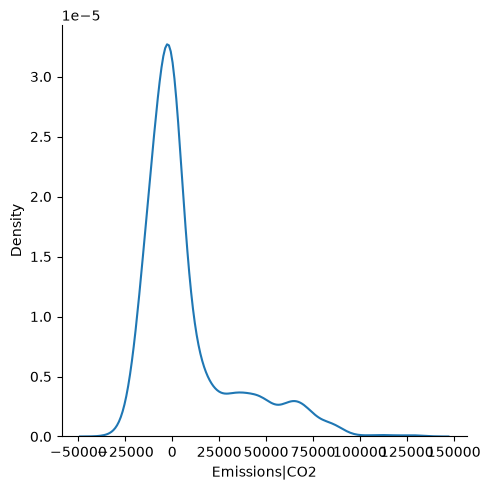

In [7]:
#examine distribution of outcome of interest

sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [8]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values<threshold_interest

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 680 cases of interest, out of 1355 scenarios


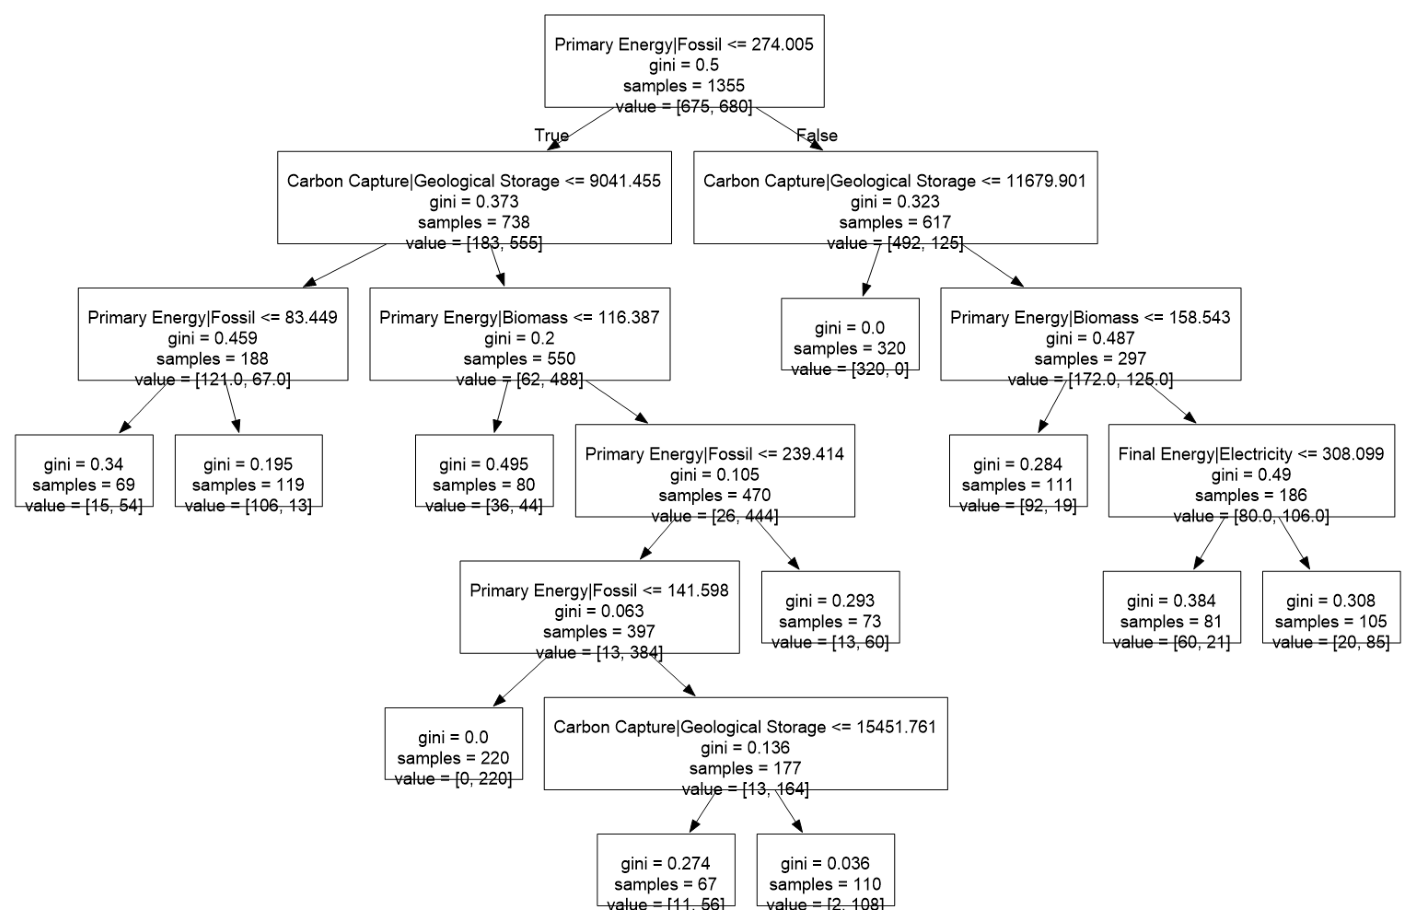

In [9]:
#CART analysis
from ema_workbench.analysis import cart

cart_alg = cart.CART(x, y)
cart_alg.build_tree()

fig = cart_alg.show_tree()
fig.set_size_inches((18, 12))
plt.show()

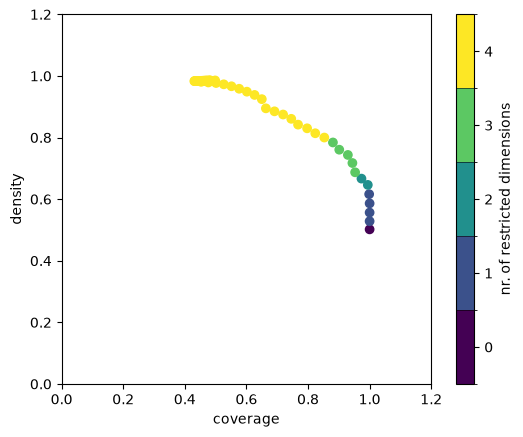

In [10]:
#PRIM analysis

#ema_logging.log_to_stderr(ema_logging.INFO);

#First box from PRIM
prim_alg = prim.Prim(x, y)
box1 = prim_alg.find_box()

#Visualize first box tradeoff
box1.show_tradeoff()
plt.show()

In [11]:
#Inspect first box tradeoff
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [12]:
#Select box
selected_box=11

coverage      0.880882
density       0.784031
id           11.000000
k           599.000000
mass          0.563838
mean          0.784031
n           764.000000
res_dim       3.000000
Name: 11, dtype: float64

                                        box 11                              \
                                           min           max      qp value   
Carbon Capture|Geological Storage  8647.960649  48733.164330  1.298400e-07   
Primary Energy|Biomass              104.916750    530.417362  7.593640e-04   
Primary Energy|Fossil                 1.849708    479.493349           NaN   

                                            
                                  qp value  
Carbon Capture|Geological Storage      NaN  
Primary Energy|Biomass                 NaN  
Primary Energy|Fossil              0.09554  



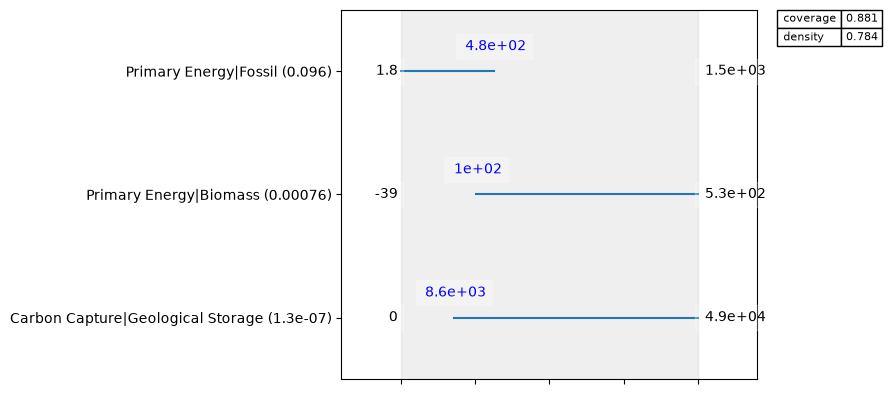

In [13]:
#Show box
box1.inspect(selected_box)
box1.inspect(selected_box, style="graph")
plt.show()